# Demo: DeepHit Competing Risks (CNN)

This notebook trains and evaluates a competing-risks DeepHit model on AAPL limit-order-book samples using a dual-stream CNN backbone.

Input streams:
- LOB features from `entry_representation` with shape (20, 41)
- Toxicity features from `toxicity_representation` plus side channel with shape (20, 19)
- Combined model input shape (20, 60)

Event coding used in this notebook:
| Event | Code |
|------|------|
| CENSORED | 0 |
| FAVORABLE_FILL | 1 |
| TOXIC_FILL | 2 |

Workflow: load data, preprocess, train DeepHit, predict CIFs, and evaluate calibration/ranking metrics.

## 1. Import Required Libraries

In [25]:
from __future__ import annotations

import os
import sys
import warnings
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from pycox.models import DeepHit
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from pycox.models.data import pair_rank_mat
from pycox.evaluation import EvalSurv

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.domain.enums import EventType

%matplotlib inline
print("PyTorch:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# CPU-only tuning: use available cores efficiently.
if device.type == "cpu":
    cpu_threads = max(1, os.cpu_count() or 1)
    torch.set_num_threads(cpu_threads)
    print(f"CPU threads configured: {cpu_threads}")

PyTorch: 2.10.0+cpu
Device: cpu
CPU threads configured: 8


## 2. Load and Explore the Dataset

The dataset is generated by `OrderTracker.process_stream` and labeled by `ExecutionCompetingRisksLabeler`.  
Key columns:
- **`duration_s`** - continuous lifetime of the virtual order (seconds)
- **`event_type`** - integer from `EventType` enum (0=censored, 1/2/3 = competing events)
- **`entry_representation`** - LOB snapshot sequence `(lookback, 2W+1)` stored as a nested list

In [26]:
DATASET_PATH = PROJECT_ROOT / "data" / "datasets" / "dataset_XNAS_ITCH_AAPL_mbo_20251001_20260101.parquet"

df_raw = pd.read_parquet(DATASET_PATH)
print("Shape:", df_raw.shape)
print("\nColumns:", list(df_raw.columns))
print("\nOriginal event type distribution:")
print(df_raw["event_type"].value_counts().sort_index().rename({v: v.name for v in EventType}))

Shape: (64000, 20)

Columns: ['best_ask_at_entry', 'best_ask_at_post_trade', 'best_bid_at_entry', 'best_bid_at_post_trade', 'duration_s', 'entry_representation', 'entry_time', 'event', 'event_time_bin', 'event_type', 'order_id', 'order_type', 'post_trade_adverse_move_bps', 'post_trade_recorded', 'post_trade_spread_bps', 'price', 'side', 'status_reason', 'toxicity_representation', 'volume']

Original event type distribution:
event_type
CENSORED            826
FAVORABLE_FILL    30311
TOXIC_FILL        32863
Name: count, dtype: int64


### 2a. Recode Event Types: Competing Fill Risks

We model **two competing risks** for fill outcomes:
- **Event 1 (FAVORABLE_FILL)**: original code `1`
- **Event 2 (TOXIC_FILL)**: original code `2`
- **Censored (0)**: original code `0`

This isolates fill quality by separating favorable and toxic fills in the hazard structure.

In [27]:
# Recode event types for competing-risks setup
df_raw["event_type_competing"] = df_raw["event_type"].copy()

label_map = {
    0: "CENSORED",
    1: "FAVORABLE_FILL",
    2: "TOXIC_FILL",
}

print("Recoded competing event distribution:")
event_counts = df_raw["event_type_competing"].value_counts().sort_index()
for code in sorted(event_counts.index):
    label = label_map.get(int(code), f"UNKNOWN_{code}")
    print(f"  {code}: {label:<30} - {event_counts[code]:>6} samples")

Recoded competing event distribution:
  0: CENSORED                       -    826 samples
  1: FAVORABLE_FILL                 -  30311 samples
  2: TOXIC_FILL                     -  32863 samples



Duration stats (seconds):
count    64000.000000
mean        12.606182
std         41.013965
min          0.000072
25%          0.527253
50%          1.802684
75%          6.376023
max        300.000000
Name: duration_s, dtype: float64


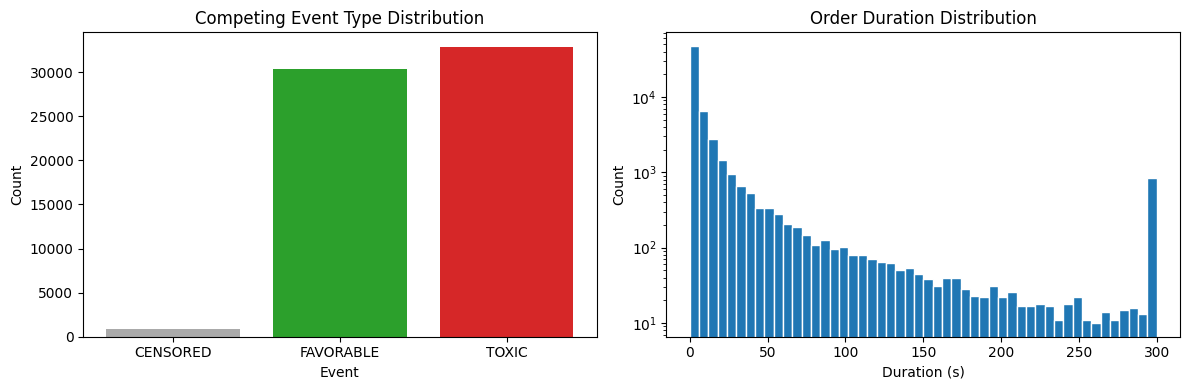

In [28]:
print("\nDuration stats (seconds):")
print(df_raw["duration_s"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Competing event distribution
event_counts = df_raw["event_type_competing"].value_counts().sort_index()
event_labels = ["CENSORED", "FAVORABLE", "TOXIC"]
bar_vals = [event_counts.get(0, 0), event_counts.get(1, 0), event_counts.get(2, 0)]
colors = ["#aaa", "#2ca02c", "#d62728"]
axes[0].bar(event_labels, bar_vals, color=colors)
axes[0].set_title("Competing Event Type Distribution")
axes[0].set_xlabel("Event")
axes[0].set_ylabel("Count")

# Duration distribution (log scale)
axes[1].hist(df_raw["duration_s"], bins=50, color="#1f77b4", edgecolor="white")
axes[1].set_title("Order Duration Distribution")
axes[1].set_xlabel("Duration (s)")
axes[1].set_ylabel("Count")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

## 3. Preprocess the Dataset

### 3a. Feature Extraction: LOB + Toxicity Dual Streams

Both `entry_representation` (LOB snapshots) and `toxicity_representation` (toxicity metrics) are `(lookback, features)` matrices covering the same temporal window.

**Processing:**
1. Extract LOB features `(N, 20, 41)` (raw market microstructure only)
2. Extract toxicity features `(N, 20, 18)` and append side as an extra channel → `(N, 20, 19)`
3. Concatenate along feature axis → `(N, 20, 60)` combined LOB+toxicity input
4. Each sample maintains temporal order, with fixed 20-step lookback

Final feature shape is `(N, 20, 60)`, which is used directly as RNN input.

In [29]:
LOOKBACK_STEPS = 20

def extract_lob_features(df: pd.DataFrame, lookback_steps: int = LOOKBACK_STEPS) -> np.ndarray:
    """Extract fixed-length LOB features for RNN input.

    Returns shape (N, lookback_steps, 41).
    - entry_representation: array of (20,) where each element is shape (41,)
    - Final: (lookback, 41)
    
    If a sample is longer than lookback_steps, keep the most recent window.
    If shorter, left-pad with the first available snapshot.
    """
    rows = []
    for rep in df["entry_representation"]:
        # rep is array of shape (20,) where each element is shape (41,)
        # Stack into (20, 41)
        arr = np.stack([np.asarray(row, dtype=np.float32) for row in rep])
        
        if arr.shape[0] >= lookback_steps:
            arr = arr[-lookback_steps:]
        else:
            pad_len = lookback_steps - arr.shape[0]
            pad = np.repeat(arr[:1], repeats=pad_len, axis=0)
            arr = np.concatenate([pad, arr], axis=0)

        rows.append(arr)

    return np.stack(rows, axis=0)


def extract_toxicity_features(df: pd.DataFrame, lookback_steps: int = LOOKBACK_STEPS) -> np.ndarray:
    """Extract fixed-length toxicity features for RNN input, appending side as extra channel.

    Returns shape (N, lookback_steps, 19).
    - toxicity_representation: array of (20,) where each element is shape (18,)
    - side is appended: (lookback, 1)
    - Final: (lookback, 19)
    
    If a sample is longer than lookback_steps, keep the most recent window.
    If shorter, left-pad with the first available snapshot.
    """
    side_raw = df["side"]
    if np.issubdtype(side_raw.dtype, np.number):
        side_vals = side_raw.astype(np.float32).to_numpy()
    else:
        side_vals = (
            side_raw.astype(str)
            .str.upper()
            .map({"B": 1.0, "A": 0.0})
            .fillna(0.5)
            .astype(np.float32)
            .to_numpy()
        )

    rows = []
    for rep, side_val in zip(df["toxicity_representation"], side_vals):
        # rep is array of shape (20,) where each element is shape (18,)
        # Stack into (20, 18)
        arr = np.stack([np.asarray(row, dtype=np.float32) for row in rep])
        
        if arr.shape[0] >= lookback_steps:
            arr = arr[-lookback_steps:]
        else:
            pad_len = lookback_steps - arr.shape[0]
            pad = np.repeat(arr[:1], repeats=pad_len, axis=0)
            arr = np.concatenate([pad, arr], axis=0)

        side_col = np.full((arr.shape[0], 1), side_val, dtype=np.float32)
        arr_with_side = np.concatenate([arr, side_col], axis=1)
        rows.append(arr_with_side)

    return np.stack(rows, axis=0)


# Extract both LOB and toxicity features
X_lob = extract_lob_features(df_raw, lookback_steps=LOOKBACK_STEPS)
X_tox = extract_toxicity_features(df_raw, lookback_steps=LOOKBACK_STEPS)

# Concatenate along feature dimension
X_all = np.concatenate([X_lob, X_tox], axis=2)

Y_all = df_raw["duration_s"].values.astype(np.float32)             # continuous durations (seconds)
D_all = df_raw["event_type_competing"].values.astype(np.int64)      # 0=censored, 1=favorable, 2=toxic

print(f"LOB features shape       : {X_lob.shape}       - (N, lookback=20, LOB_features=41)")
print(f"Toxicity features shape  : {X_tox.shape}       - (N, lookback=20, toxicity_features=19)")
print(f"Combined features shape  : {X_all.shape}     - (N, lookback=20, combined_features=60)")
print(f"Duration vector shape    : {Y_all.shape}")
print(f"Event vector shape       : {D_all.shape}")
print(f"Unique event codes       : {sorted(np.unique(D_all).tolist())}")

LOB features shape       : (64000, 20, 41)       - (N, lookback=20, LOB_features=41)
Toxicity features shape  : (64000, 20, 19)       - (N, lookback=20, toxicity_features=19)
Combined features shape  : (64000, 20, 60)     - (N, lookback=20, combined_features=60)
Duration vector shape    : (64000,)
Event vector shape       : (64000,)
Unique event codes       : [0, 1, 2]


### 3b. Train / Validation / Test Split

In [30]:
SEED = 4718

# Day-boundary temporal split
# We extract the trading date for each order and choose the split points
# so that each partition starts cleanly at the beginning of a new day.

entry_ns = df_raw["entry_time"].values
dates = pd.to_datetime(entry_ns, unit="ns", utc=True).tz_convert("America/New_York").normalize()

unique_days = sorted(dates.unique())
n_days = len(unique_days)
print(f"Dataset spans {n_days} trading days: {unique_days[0].date()} to {unique_days[-1].date()}")

# Pick the day boundaries nearest to the 70 / 85 percentile of total rows
n = len(df_raw)
target_train_end = int(n * 0.70)
target_val_end   = int(n * 0.85)

# Cumulative row counts at the END of each day
day_end_idx = [(dates <= d).sum() - 1 for d in unique_days]   # last row index of each day

def _best_day_cut(target_row: int) -> int:
    """Return the index of the day whose END row is closest to target_row."""
    return min(range(n_days), key=lambda i: abs(day_end_idx[i] - target_row))

train_day_idx = _best_day_cut(target_train_end)
val_day_idx   = _best_day_cut(target_val_end)
train_day_idx = min(train_day_idx, n_days - 3)
val_day_idx   = max(train_day_idx + 1, min(val_day_idx, n_days - 2))

train_end = day_end_idx[train_day_idx] + 1
val_end   = day_end_idx[val_day_idx]   + 1

idx = np.arange(n)
train_mask = idx < train_end
val_mask   = (idx >= train_end) & (idx < val_end)
test_mask  = idx >= val_end

X_train, Y_train, D_train = X_all[train_mask], Y_all[train_mask], D_all[train_mask]
X_val,   Y_val,   D_val   = X_all[val_mask],   Y_all[val_mask],   D_all[val_mask]
X_test,  Y_test,  D_test  = X_all[test_mask],  Y_all[test_mask],  D_all[test_mask]

train_days = unique_days[:train_day_idx + 1]
val_days   = unique_days[train_day_idx + 1 : val_day_idx + 1]
test_days  = unique_days[val_day_idx + 1:]

print("Using full temporal splits without train/val subsampling:")
print(f"  Train samples: {len(X_train):,} over {len(train_days)} day(s)")
print(f"  Val samples  : {len(X_val):,} over {len(val_days)} day(s)")
print(f"  Test samples : {len(X_test):,} over {len(test_days)} day(s)")

Dataset spans 64 trading days: 2025-10-01 to 2025-12-31
Using full temporal splits without train/val subsampling:
  Train samples: 45,000 over 45 day(s)
  Val samples  : 9,000 over 9 day(s)
  Test samples : 10,000 over 10 day(s)


### 3c. Feature Normalisation

Standardise each feature using training-set mean and standard deviation (prevents data leakage).
For sequential data `(N, 20, F)`, normalization is applied feature-wise using train statistics over sample and time axes.


In [31]:
feat_mean = X_train.mean(axis=(0, 1), keepdims=True)  # Average over samples and time
feat_std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_np = ((X_train - feat_mean) / feat_std).astype(np.float32)
X_val_np   = ((X_val   - feat_mean) / feat_std).astype(np.float32)
X_test_np  = ((X_test  - feat_mean) / feat_std).astype(np.float32)

print(f"Normalized feature range - Train: [{X_train_np.min():.3f}, {X_train_np.max():.3f}]")

Normalized feature range - Train: [-113.860, 220.134]


### 3d. Discretise Continuous Durations

Following the reference implementation, we use PyCox's `LabTransDiscreteTime` for quantile-based binning.
Only uncensored events inform the grid construction.

In [32]:
class LabTransform(LabTransDiscreteTime):
    """Extends LabTransDiscreteTime to keep competing event codes (1..K)."""
    def transform(self, durations, events):
        durations, is_event = super().transform(durations, events > 0)
        events = events.astype("int64")
        events[is_event == 0] = 0
        return durations, events


NUM_TIME_STEPS = 30
if not (20 <= NUM_TIME_STEPS <= 40):
    raise ValueError("NUM_TIME_STEPS must be between 20 and 40.")

label_transform = LabTransform(NUM_TIME_STEPS, scheme="quantiles")

Y_train_disc, D_train_disc = label_transform.fit_transform(Y_train.copy(), D_train.copy())
Y_val_disc,   D_val_disc   = label_transform.transform(Y_val.copy(),   D_val.copy())

time_grid = label_transform.cuts
output_steps = len(time_grid)

print(f"Requested time steps : {NUM_TIME_STEPS}")
print(f"Actual time steps    : {output_steps}")
print(f"Time grid (seconds)  : {np.round(time_grid, 3)}")
print(f"Train event codes    : {sorted(np.unique(D_train_disc).tolist())}")

Requested time steps : 30
Actual time steps    : 30
Time grid (seconds)  : [0.0000e+00 2.7000e-02 5.8000e-02 9.2000e-02 1.2900e-01 1.7000e-01
 2.1600e-01 2.6700e-01 3.2100e-01 3.8200e-01 4.5000e-01 5.2700e-01
 6.0700e-01 7.0100e-01 8.0800e-01 9.2800e-01 1.0600e+00 1.2110e+00
 1.4020e+00 1.6160e+00 1.8750e+00 2.1810e+00 2.5680e+00 3.0730e+00
 3.7830e+00 4.7870e+00 6.3130e+00 9.0090e+00 1.6312e+01 3.0000e+02]
Train event codes    : [0, 1, 2]


### 3e. Build PyTorch Datasets

In [33]:
def make_tensors(X_np, Y_disc_np, D_disc_np):
    # RNN input stays as (N, lookback, features).
    X = torch.tensor(X_np, dtype=torch.float32, device=device)
    Y = torch.tensor(Y_disc_np, dtype=torch.int64, device=device)
    D = torch.tensor(D_disc_np, dtype=torch.int64, device=device)
    return X, Y, D


X_train_t, Y_train_t, D_train_t = make_tensors(X_train_np, Y_train_disc, D_train_disc)
X_val_t, Y_val_t, D_val_t = make_tensors(X_val_np, Y_val_disc, D_val_disc)

train_data = list(zip(X_train_t, Y_train_t, D_train_t))
val_data = list(zip(X_val_t, Y_val_t, D_val_t))

print(f"Train tensor: X={tuple(X_train_t.shape)}, Y={tuple(Y_train_t.shape)}, D={tuple(D_train_t.shape)}")
print(f"Val tensor: X={tuple(X_val_t.shape)}, Y={tuple(Y_val_t.shape)}, D={tuple(D_val_t.shape)}")

Train tensor: X=(45000, 20, 60), Y=(45000,), D=(45000,)
Val tensor: X=(9000, 20, 60), Y=(9000,), D=(9000,)


## 4. Define the DeepHit Architecture

The competing-risks DeepHit model uses a **GRU-based RNN backbone** with dual input streams and outputs a joint cause-time tensor:
- **Dual input streams**: Concatenated LOB + toxicity features `(batch, 20, 60)`
  - LOB microstructure (41 features)
  - Toxicity metrics (19 features, including side)
- **Survival output**: `(batch, K, T)` where `K=2` competing events and `T` is discrete time steps
- **Event heads**: `FAVORABLE_FILL` and `TOXIC_FILL`

PyCox's `DeepHit` applies a joint softmax over the `K x T` logits to form a joint PMF over `(cause, time)` and derives cause-specific CIFs from that PMF.

In [34]:
# Hyperparameters
NUM_COMPETING_EVENTS = 2
EVENT_NAMES = ["FAVORABLE_FILL", "TOXIC_FILL"]
EVENT_CODES = [1, 2]

CPU_QUICK_MODE = device.type == "cpu"

# CNN Architecture (dual-stream: 2D CNN for LOB, 1D CNN for toxicity)
# Note: RNN_HIDDEN_SIZE and RNN_NUM_LAYERS are kept for backward compatibility
#       but don't directly apply to CNN architecture
RNN_HIDDEN_SIZE = 128 if CPU_QUICK_MODE else 160
RNN_NUM_LAYERS = 1 if CPU_QUICK_MODE else 2
RNN_DROPOUT = 0.0 if RNN_NUM_LAYERS == 1 else 0.2
FC_DROPOUT = 0.2

# DeepHit loss
ALPHA = 0.5
SIGMA = 0.1

# Optimisation
LEARNING_RATE = 5e-4
BATCH_SIZE = 512 if CPU_QUICK_MODE else 1024
NUM_EPOCHS = 100
EARLY_STOP_PATIENCE = 12
if not (80 <= NUM_EPOCHS <= 120):
    raise ValueError("NUM_EPOCHS must be between 80 and 120.")
if not (10 <= EARLY_STOP_PATIENCE <= 15):
    raise ValueError("EARLY_STOP_PATIENCE must be between 10 and 15.")

print("Configuration:")
for k, v in {
    "Competing events": NUM_COMPETING_EVENTS,
    "Event names": EVENT_NAMES,
    "Lookback steps": LOOKBACK_STEPS,
    "RNN hidden size": RNN_HIDDEN_SIZE,
    "RNN layers": RNN_NUM_LAYERS,
    "RNN dropout": RNN_DROPOUT,
    "LR": LEARNING_RATE,
    "Batch size": BATCH_SIZE,
    "Epochs": NUM_EPOCHS,
    "Early stop patience": EARLY_STOP_PATIENCE,
}.items():

    print(f"  {k:<22}: {v}")

Configuration:
  Competing events      : 2
  Event names           : ['FAVORABLE_FILL', 'TOXIC_FILL']
  Lookback steps        : 20
  RNN hidden size       : 128
  RNN layers            : 1
  RNN dropout           : 0.0
  LR                    : 0.0005
  Batch size            : 512
  Epochs                : 100
  Early stop patience   : 12


### 5a. Build Competing-Risks CNN

Define a dual-stream CNN backbone that outputs:

- **LOB stream (2D CNN)**: Convolves across time with temporal kernels (3×1) on LOB features
- **Toxicity stream (1D CNN)**: Convolves across time with size-3 kernels on toxicity metrics  
- **Survival logits**: shape `(batch, K, T)` for DeepHit competing risks (`K=2` fill outcomes, `T` time bins)

In [35]:
torch.manual_seed(SEED)

class DeepHitCNNCompeting(nn.Module):
    """Dual-stream CNN backbone for DeepHit competing risks.
    
    - LOB stream: 2D CNN on LOB features (batch, 20, 41)
      Convolves across time dimension with (3x1) temporal kernels
    - Toxicity stream: 1D CNN on toxicity metrics (batch, 20, 19)
      Convolves across time dimension with size-3 kernels
    - Both streams pooled and concatenated for joint representation

    Input shape:  (batch, lookback_steps, num_features)
    num_features = 60 (41 LOB + 19 toxicity features)
    Output shape: (batch, num_events, num_time_steps)
    """
    def __init__(
        self,
        num_features: int,
        num_events: int,
        num_time_steps: int,
        hidden_size: int = 160,
        num_layers: int = 2,
        rnn_dropout: float = 0.2,
        fc_dropout: float = 0.2,
    ):
        super().__init__()
        self.num_events = num_events
        self.num_time_steps = num_time_steps

        # LOB stream: 2D CNN (convolve across time dimension)
        # Input: (batch, 20, 41) -> reshape to (batch, 1, 20, 41)
        # Temporal kernels (3x1) convolve over time axis
        self.lob_conv1 = nn.Conv2d(1, 32, kernel_size=(3, 1), padding=(1, 0), stride=(1, 1))
        self.lob_bn1 = nn.BatchNorm2d(32)
        self.lob_conv2 = nn.Conv2d(32, 64, kernel_size=(3, 1), padding=(1, 0), stride=(1, 1))
        self.lob_bn2 = nn.BatchNorm2d(64)
        self.lob_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Toxicity stream: 1D CNN (convolve across time dimension)
        # Input: (batch, 20, 19) -> transpose to (batch, 19, 20)
        # Temporal kernels (size 3) convolve over time axis
        self.tox_conv1 = nn.Conv1d(19, 32, kernel_size=3, padding=1)
        self.tox_bn1 = nn.BatchNorm1d(32)
        self.tox_conv2 = nn.Conv1d(32, 32, kernel_size=3, padding=1)
        self.tox_bn2 = nn.BatchNorm1d(32)
        self.tox_pool = nn.AdaptiveAvgPool1d(1)

        # Combined FC head for survival logits
        # After pooling: LOB stream (64) + Toxicity stream (32) = 96 dims
        combined_dim = 64 + 32
        fc_hidden = 128 if CPU_QUICK_MODE else 256

        self.fc = nn.Sequential(
            nn.Linear(combined_dim, fc_hidden),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(fc_hidden),
            nn.Dropout(fc_dropout),
            nn.Linear(fc_hidden, num_events * num_time_steps),
        )

    def forward(self, x: torch.Tensor):
        # x shape: (batch, 20, 60)
        batch_size = x.size(0)

        # Split into LOB (first 41 features) and toxicity (last 19 features)
        lob_feat = x[:, :, :41]        # (batch, 20, 41)
        tox_feat = x[:, :, 41:]        # (batch, 20, 19)

        # LOB stream: 2D CNN
        lob_in = lob_feat.unsqueeze(1)  # (batch, 1, 20, 41)
        lob_out = self.lob_bn1(self.lob_conv1(lob_in))  # (batch, 32, 20, 41)
        lob_out = torch.relu(lob_out)
        lob_out = self.lob_bn2(self.lob_conv2(lob_out))  # (batch, 64, 20, 41)
        lob_out = torch.relu(lob_out)
        lob_out = self.lob_pool(lob_out)  # (batch, 64, 1, 1)
        lob_out = lob_out.view(batch_size, -1)  # (batch, 64)

        # Toxicity stream: 1D CNN
        tox_in = tox_feat.transpose(1, 2)  # (batch, 19, 20) - channels first for Conv1d
        tox_out = self.tox_bn1(self.tox_conv1(tox_in))  # (batch, 32, 20)
        tox_out = torch.relu(tox_out)
        tox_out = self.tox_bn2(self.tox_conv2(tox_out))  # (batch, 32, 20)
        tox_out = torch.relu(tox_out)
        tox_out = self.tox_pool(tox_out)  # (batch, 32, 1)
        tox_out = tox_out.view(batch_size, -1)  # (batch, 32)

        # Concatenate both streams
        combined = torch.cat([lob_out, tox_out], dim=1)  # (batch, 96)

        # FC head for survival logits
        return self.fc(combined).view(batch_size, self.num_events, self.num_time_steps)

In [36]:
feature_dim = X_train_t.size(2)

base_net = DeepHitCNNCompeting(
    num_features=feature_dim,
    num_events=NUM_COMPETING_EVENTS,
    num_time_steps=output_steps,
    hidden_size=RNN_HIDDEN_SIZE,
    num_layers=RNN_NUM_LAYERS,
    rnn_dropout=RNN_DROPOUT,
    fc_dropout=FC_DROPOUT,
).to(device)

deephit_model = DeepHit(
    base_net,
    alpha=ALPHA,
    sigma=SIGMA,
    device=device,
    duration_index=time_grid,
)

total_params = sum(p.numel() for p in base_net.parameters() if p.requires_grad)
print(f"Input shape      : {tuple(X_train_t.shape)}")
print(f"Lookback steps   : {X_train_t.size(1)}")
print(f"Feature dim      : {feature_dim} (41 LOB + 19 toxicity)")
print(f"Output (K, T)    : ({NUM_COMPETING_EVENTS}, {output_steps})")
print(f"Trainable params : {total_params:,}")

Input shape      : (45000, 20, 60)
Lookback steps   : 20
Feature dim      : 60 (41 LOB + 19 toxicity)
Output (K, T)    : (2, 30)
Trainable params : 32,028


In [37]:
from torchsummary import summary
summary(base_net, input_size=(LOOKBACK_STEPS, feature_dim), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 20, 41]             128
       BatchNorm2d-2           [-1, 32, 20, 41]              64
            Conv2d-3           [-1, 64, 20, 41]           6,208
       BatchNorm2d-4           [-1, 64, 20, 41]             128
 AdaptiveAvgPool2d-5             [-1, 64, 1, 1]               0
            Conv1d-6               [-1, 32, 20]           1,856
       BatchNorm1d-7               [-1, 32, 20]              64
            Conv1d-8               [-1, 32, 20]           3,104
       BatchNorm1d-9               [-1, 32, 20]              64
AdaptiveAvgPool1d-10                [-1, 32, 1]               0
           Linear-11                  [-1, 128]          12,416
             ReLU-12                  [-1, 128]               0
      BatchNorm1d-13                  [-1, 128]             256
          Dropout-14                  [

## 6. Train the DeepHit Model

Training uses mini-batch gradient descent with the DeepHit competing-risks loss.  
Model parameters from the epoch with the **lowest validation loss** are retained.

In [38]:
# Data loading tuned for CPU/GPU differences.
if device.type == "cpu":
    train_loader = DataLoader(train_data, BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_data, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
else:
    train_loader = DataLoader(train_data, BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_data, BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

optimizer = torch.optim.Adam(base_net.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=LEARNING_RATE * 0.1
)

train_losses, val_losses = [], []
best_val_loss = float("inf")
best_params = None
best_epoch_idx = None
epochs_no_improve = 0

# Training loop with early stopping.
for epoch in range(NUM_EPOCHS):
    base_net.train()
    epoch_loss = 0.0
    n_batches = 0

    for X_b, Y_b, D_b in train_loader:
        optimizer.zero_grad()

        surv_logits = base_net(X_b)

        rm = pair_rank_mat(Y_b.cpu().numpy(), D_b.cpu().numpy())
        rm_t = torch.tensor(rm, dtype=torch.int, device=device)
        loss = deephit_model.loss(surv_logits, Y_b, D_b, rm_t)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    train_loss = epoch_loss / n_batches

    base_net.eval()
    val_loss_total = 0.0
    n_val_batches = 0

    with torch.no_grad():
        for X_b, Y_b, D_b in val_loader:
            surv_logits = base_net(X_b)

            rm = pair_rank_mat(Y_b.cpu().numpy(), D_b.cpu().numpy())
            rm_t = torch.tensor(rm, dtype=torch.int, device=device)
            loss = deephit_model.loss(surv_logits, Y_b, D_b, rm_t)

            val_loss_total += loss.item()
            n_val_batches += 1

    val_loss = val_loss_total / n_val_batches

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch_idx = epoch
        best_params = deepcopy(base_net.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 2 == 0:
        print(
            f"Epoch {epoch+1:>3}/{NUM_EPOCHS}  "
            f"train={train_loss:.4f}  val={val_loss:.4f}  "
            f"(no improve: {epochs_no_improve})"
        )

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} (val loss did not improve for {EARLY_STOP_PATIENCE} epochs)")
        break

base_net.load_state_dict(best_params)
print(f"\nBest val loss {best_val_loss:.4f} at epoch {best_epoch_idx + 1}")

Epoch   2/100  train=2.3361  val=2.2983  (no improve: 0)
Epoch   4/100  train=2.2911  val=2.2638  (no improve: 0)
Epoch   6/100  train=2.2682  val=2.2462  (no improve: 0)
Epoch   8/100  train=2.2527  val=2.2381  (no improve: 0)
Epoch  10/100  train=2.2418  val=2.2389  (no improve: 1)
Epoch  12/100  train=2.2347  val=2.2299  (no improve: 0)
Epoch  14/100  train=2.2297  val=2.2268  (no improve: 0)
Epoch  16/100  train=2.2272  val=2.2245  (no improve: 0)
Epoch  18/100  train=2.2274  val=2.2239  (no improve: 1)
Epoch  20/100  train=2.2181  val=2.2191  (no improve: 0)
Epoch  22/100  train=2.2152  val=2.2198  (no improve: 2)
Epoch  24/100  train=2.2109  val=2.2173  (no improve: 0)
Epoch  26/100  train=2.2045  val=2.2121  (no improve: 0)
Epoch  28/100  train=2.2021  val=2.2127  (no improve: 2)
Epoch  30/100  train=2.1995  val=2.2108  (no improve: 0)
Epoch  32/100  train=2.2018  val=2.2142  (no improve: 2)
Epoch  34/100  train=2.1998  val=2.2147  (no improve: 4)
Epoch  36/100  train=2.1940  va

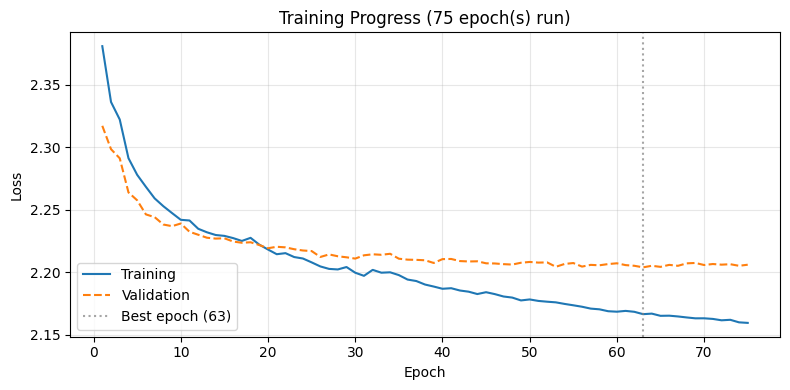


Best epoch 63:
  Train loss: 2.1663
  Val loss  : 2.2038


In [39]:
num_epochs_ran = min(len(train_losses), len(val_losses))
if num_epochs_ran == 0:
    raise RuntimeError("No training history found. Run training cell first.")

epochs = range(1, num_epochs_ran + 1)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(epochs, train_losses[:num_epochs_ran], label="Training", color="#1f77b4")
ax.plot(epochs, val_losses[:num_epochs_ran], "--", label="Validation", color="#ff7f0e")

best_epoch_display = (best_epoch_idx + 1) if best_epoch_idx is not None else None
if best_epoch_display is not None and 1 <= best_epoch_display <= num_epochs_ran:
    ax.axvline(
        best_epoch_display,
        color="grey",
        linestyle=":",
        alpha=0.7,
        label=f"Best epoch ({best_epoch_display})",
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"Training Progress ({num_epochs_ran} epoch(s) run)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_idx = best_epoch_idx if best_epoch_idx is not None else num_epochs_ran - 1
print(f"\nBest epoch {best_epoch_display}:")
print(f"  Train loss: {train_losses[best_idx]:.4f}")
print(f"  Val loss  : {val_losses[best_idx]:.4f}")

## 7. Evaluate Model Performance

### 7a. Predict Cause-Specific CIFs on the Test Set

`deephit_model.predict_cif` returns an array of shape `(K, T, N)` where:
- `K` = number of competing events (`2`: favorable, toxic)
- `T` = discrete time steps
- `N` = number of test samples

In [40]:
base_net.eval()

# cif_test shape: (K, T, N_test)
cif_test = deephit_model.predict_cif(
    X_test_np.astype("float32"),
    batch_size=BATCH_SIZE,
    to_cpu=True,
    numpy=True,
)

print(f"CIF array shape: {cif_test.shape}   (K=events, T=time_steps, N=test_samples)")
print(f"CIF range: [{cif_test.min():.4f}, {cif_test.max():.4f}]")

print(f"\nFor test sample 0 at t={time_grid[-1]:.1f}s:")
total_fill_prob = 0.0
for k, name in enumerate(EVENT_NAMES):
    p = float(cif_test[k, -1, 0])
    total_fill_prob += p
    print(f"  CIF({name}) = {p:.4f}")
print(f"  CIF(ANY_FILL) = {total_fill_prob:.4f}")
print(f"  Survival      = {1.0 - total_fill_prob:.4f}")

CIF array shape: (2, 30, 10000)   (K=events, T=time_steps, N=test_samples)
CIF range: [0.0000, 0.7733]

For test sample 0 at t=300.0s:
  CIF(FAVORABLE_FILL) = 0.4453
  CIF(TOXIC_FILL) = 0.5327
  CIF(ANY_FILL) = 0.9780
  Survival      = 0.0220


### 7b. Distribution of Predicted Cause-Specific Fill Probabilities

Compare final-time CIF predictions for favorable and toxic risks across true outcome groups.

Test set composition:
  CENSORED      : 332
  FAVORABLE_FILL: 4898
  TOXIC_FILL    : 4770

Predicted final CIF means at t=300.0s:
  True FAVORABLE -> CIF(FAVORABLE): 0.4706
  True TOXIC     -> CIF(TOXIC)    : 0.5280


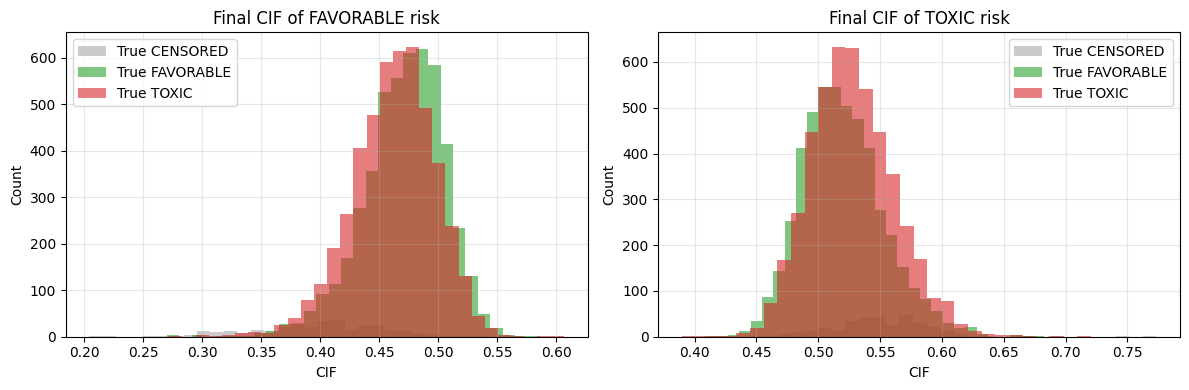

In [41]:
# Final-time cause-specific probabilities
final_cif_fav = cif_test[0, -1, :]
final_cif_tox = cif_test[1, -1, :]

mask_cens = (D_test == 0)
mask_fav = (D_test == 1)
mask_tox = (D_test == 2)

print("Test set composition:")
print(f"  CENSORED      : {int(mask_cens.sum())}")
print(f"  FAVORABLE_FILL: {int(mask_fav.sum())}")
print(f"  TOXIC_FILL    : {int(mask_tox.sum())}")

print(f"\nPredicted final CIF means at t={time_grid[-1]:.1f}s:")
print(f"  True FAVORABLE -> CIF(FAVORABLE): {final_cif_fav[mask_fav].mean():.4f}")
print(f"  True TOXIC     -> CIF(TOXIC)    : {final_cif_tox[mask_tox].mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Favorable-risk distribution
axes[0].hist(final_cif_fav[mask_cens], bins=30, alpha=0.5, label="True CENSORED", color="#999999")
axes[0].hist(final_cif_fav[mask_fav], bins=30, alpha=0.6, label="True FAVORABLE", color="#2ca02c")
axes[0].hist(final_cif_fav[mask_tox], bins=30, alpha=0.6, label="True TOXIC", color="#d62728")
axes[0].set_title("Final CIF of FAVORABLE risk")
axes[0].set_xlabel("CIF")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Toxic-risk distribution
axes[1].hist(final_cif_tox[mask_cens], bins=30, alpha=0.5, label="True CENSORED", color="#999999")
axes[1].hist(final_cif_tox[mask_fav], bins=30, alpha=0.6, label="True FAVORABLE", color="#2ca02c")
axes[1].hist(final_cif_tox[mask_tox], bins=30, alpha=0.6, label="True TOXIC", color="#d62728")
axes[1].set_title("Final CIF of TOXIC risk")
axes[1].set_xlabel("CIF")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7c. Cause-Specific Concordance

Compute time-dependent concordance for each competing event by treating the other event as censoring for that cause-specific evaluation.

In [42]:
print("Time-dependent Concordance Index (Antolini) per competing event:")

ctd_scores = {}
for k, (event_code, event_name) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
    one_minus_cif_df = pd.DataFrame(
        1 - cif_test[k, :, :],
        index=time_grid,
    )

    ev = EvalSurv(
        one_minus_cif_df,
        Y_test,
        (D_test == event_code).astype(int),
        censor_surv="km",
    )

    ctd = ev.concordance_td("antolini")
    ctd_scores[event_name] = ctd
    print(f"  {event_name:<20}: C-td = {ctd:.4f}")

macro_ctd = float(np.mean(list(ctd_scores.values())))
print(f"\nMacro-average C-td: {macro_ctd:.4f}")

Time-dependent Concordance Index (Antolini) per competing event:
  FAVORABLE_FILL      : C-td = 0.6394
  TOXIC_FILL          : C-td = 0.5788

Macro-average C-td: 0.6091


### 7d. Integrated Brier Score

The integrated Brier score measures the average squared difference between predicted and observed survival probabilities over time.  
Lower scores indicate better calibration.

  FAVORABLE_FILL      : BS range [0.0000, 0.2456]
  TOXIC_FILL          : BS range [0.0000, 0.2499]

Integrated Brier Score (IBS) per event:
  FAVORABLE_FILL      : IBS = 0.2359
  TOXIC_FILL          : IBS = 0.2457

Macro-average IBS: 0.2408
Reference: IBS=0.25 for an uninformative model


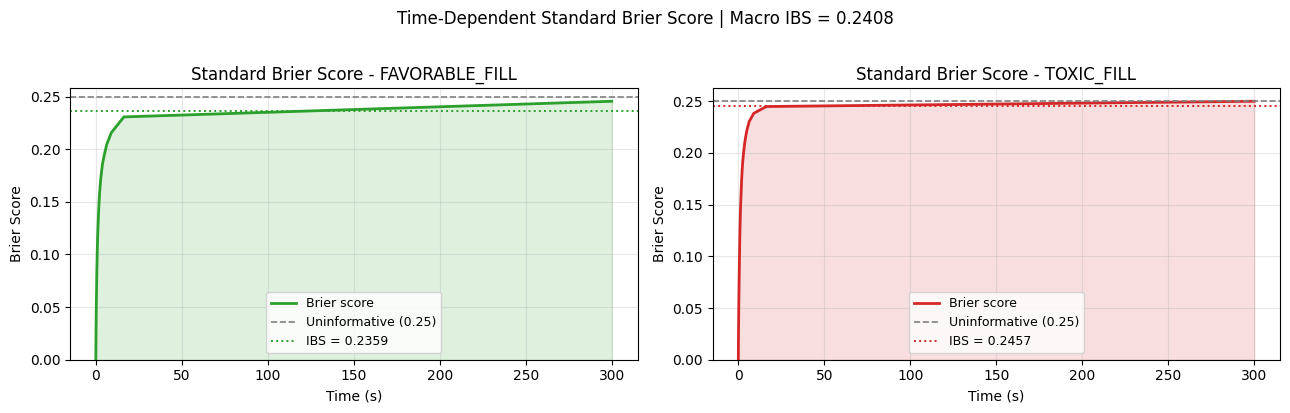

In [47]:
def standard_brier_score(
    durations: np.ndarray,
    events: np.ndarray,
    cif_k: np.ndarray,
    event_code: int,
    time_grid: np.ndarray,
) -> np.ndarray:
    """Compute standard Brier score for a specific cause at each time point."""
    T = len(time_grid)
    bs = np.zeros(T)

    for j, t in enumerate(time_grid):
        label = ((durations <= t) & (events == event_code)).astype(float)
        residual = (label - cif_k[j, :]) ** 2
        bs[j] = np.mean(residual)

    return bs

# Compute Brier score curves for each event.
bs_curves = {}
for k, (event_code, event_name) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
    bs_curves[event_name] = standard_brier_score(
        durations=Y_test,
        events=D_test,
        cif_k=cif_test[k],
        event_code=event_code,
        time_grid=time_grid,
)
    print(f"  {event_name:<20}: BS range [{bs_curves[event_name].min():.4f}, {bs_curves[event_name].max():.4f}]")

# Integrated Brier score (IBS) via trapezoidal integration.
t_min, t_max = time_grid[0], time_grid[-1]
_trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

ibs_scores = {}
for event_name, bs_arr in bs_curves.items():
    ibs_scores[event_name] = _trapz(bs_arr, time_grid) / (t_max - t_min)

macro_ibs = float(np.mean(list(ibs_scores.values())))

print("\nIntegrated Brier Score (IBS) per event:")
for event_name, ibs in ibs_scores.items():
    print(f"  {event_name:<20}: IBS = {ibs:.4f}")
print(f"\nMacro-average IBS: {macro_ibs:.4f}")
print("Reference: IBS=0.25 for an uninformative model")

colors_bs = {"FAVORABLE_FILL": "#2ca02c", "TOXIC_FILL": "#d62728"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, (event_name, bs_arr) in zip(axes, bs_curves.items()):
    ibs_val = ibs_scores[event_name]
    color = colors_bs.get(event_name, "#1f77b4")

    ax.plot(time_grid, bs_arr, color=color, linewidth=2, label="Brier score")
    ax.fill_between(time_grid, bs_arr, alpha=0.15, color=color)
    ax.axhline(0.25, color="grey", linestyle="--", linewidth=1.2, label="Uninformative (0.25)")
    ax.axhline(ibs_val, color=color, linestyle=":", linewidth=1.4, label=f"IBS = {ibs_val:.4f}")
    ax.set_title(f"Standard Brier Score - {event_name}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Brier Score")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle(f"Time-Dependent Standard Brier Score | Macro IBS = {macro_ibs:.4f}", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 7e. Visualize Competing CIFs for Sample Orders

Plot favorable-risk CIF, toxic-risk CIF, and implied survival for sample test orders.

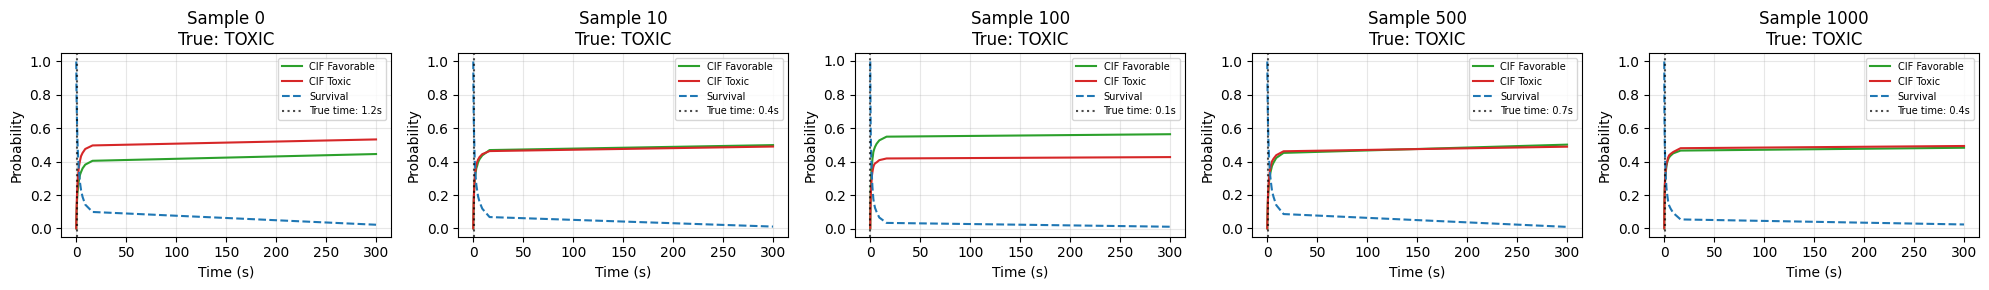

In [43]:
# Select a few sample orders to visualize
sample_indices = [0, 10, 100, 500, 1000]
sample_indices = [i for i in sample_indices if i < len(X_test)]

fig, axes = plt.subplots(1, len(sample_indices), figsize=(4 * len(sample_indices), 3))
if len(sample_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, sample_indices):
    cif_fav = cif_test[0, :, idx]
    cif_tox = cif_test[1, :, idx]
    surv_curve = 1.0 - (cif_fav + cif_tox)

    true_time = Y_test[idx]
    true_event = int(D_test[idx])
    if true_event == 1:
        true_label = "FAVORABLE"
    elif true_event == 2:
        true_label = "TOXIC"
    else:
        true_label = "CENSORED"

    ax.plot(time_grid, cif_fav, label="CIF Favorable", color="#2ca02c")
    ax.plot(time_grid, cif_tox, label="CIF Toxic", color="#d62728")
    ax.plot(time_grid, surv_curve, label="Survival", color="#1f77b4", linestyle="--")
    ax.axvline(true_time, color="black", linestyle=":", alpha=0.7, label=f"True time: {true_time:.1f}s")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Probability")
    ax.set_title(f"Sample {idx}\nTrue: {true_label}")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7f. Event Classification Metrics and Stratified CIFs

Report event-classification quality (accuracy, precision, F1) using final-time probabilities, then compare average favorable/toxic CIF curves across true outcome groups.

In [44]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Use final-time probabilities to classify event type:
# 0 = CENSORED, 1 = FAVORABLE, 2 = TOXIC
final_cif_fav = cif_test[0, -1, :]
final_cif_tox = cif_test[1, -1, :]
final_surv = np.clip(1.0 - (final_cif_fav + final_cif_tox), 0.0, 1.0)

proba_event = np.vstack([final_surv, final_cif_fav, final_cif_tox]).T  # (N, 3)
y_true = D_test.astype(int)
y_pred = proba_event.argmax(axis=1).astype(int)

In [48]:
# Final-time CIF diagnostics for event classification and censoring behavior.
final_cif_fav = cif_test[0, -1, :]
final_cif_tox = cif_test[1, -1, :]
final_surv = np.clip(1.0 - (final_cif_fav + final_cif_tox), 0.0, 1.0)

# 1) Event-only classification: FAVORABLE vs TOXIC (exclude censored).
has_event_mask = (y_true == 1) | (y_true == 2)
y_true_events = y_true[has_event_mask]
final_cif_fav_events = final_cif_fav[has_event_mask]
final_cif_tox_events = final_cif_tox[has_event_mask]
y_pred_events = np.where(final_cif_fav_events > final_cif_tox_events, 1, 2)

event_labels = [1, 2]
event_names = ["FAVORABLE", "TOXIC"]

acc_events = accuracy_score(y_true_events, y_pred_events)
prec_macro_ev, rec_macro_ev, f1_macro_ev, _ = precision_recall_fscore_support(
    y_true_events, y_pred_events, labels=event_labels, average="macro", zero_division=0
)
prec_weighted_ev, rec_weighted_ev, f1_weighted_ev, _ = precision_recall_fscore_support(
    y_true_events, y_pred_events, labels=event_labels, average="weighted", zero_division=0
)
prec_cls_ev, rec_cls_ev, f1_cls_ev, support_cls_ev = precision_recall_fscore_support(
    y_true_events, y_pred_events, labels=event_labels, average=None, zero_division=0
)

print("Event-only classification (FAVORABLE vs TOXIC)")
print(f"Samples with events: {int(has_event_mask.sum())} / {len(y_true)} ({100 * has_event_mask.mean():.1f}%)")
print(f"Accuracy         : {acc_events:.4f}")
print(f"Precision (macro): {prec_macro_ev:.4f}")
print(f"Recall (macro)   : {rec_macro_ev:.4f}")
print(f"F1 (macro)       : {f1_macro_ev:.4f}")
print(f"Precision (wgt)  : {prec_weighted_ev:.4f}")
print(f"Recall (wgt)     : {rec_weighted_ev:.4f}")
print(f"F1 (wgt)         : {f1_weighted_ev:.4f}")

print("\nPer-class metrics:")
for i, name in enumerate(event_names):
    print(
        f"  {name:<10}  precision={prec_cls_ev[i]:.4f}  recall={rec_cls_ev[i]:.4f}  "
        f"f1={f1_cls_ev[i]:.4f}  n={int(support_cls_ev[i])}"
    )

cm_events = confusion_matrix(y_true_events, y_pred_events, labels=event_labels)
cm_events_df = pd.DataFrame(
    cm_events,
    index=[f"true_{n}" for n in event_names],
    columns=[f"pred_{n}" for n in event_names],
)
print("\nConfusion matrix (event samples only):")
display(cm_events_df)

# 2) Censoring diagnostics via final-time survival probability.
is_censored = y_true == 0
n_censored = int(is_censored.sum())
surv_prob_censored = final_surv[is_censored]
surv_prob_events = final_surv[has_event_mask]

avg_surv_censored = surv_prob_censored.mean()
avg_surv_events = surv_prob_events.mean()
threshold = 0.5
correct_cens = (surv_prob_censored > threshold).sum()

print("\nCensoring diagnostics")
print(f"Censored samples: {n_censored} / {len(y_true)} ({100 * is_censored.mean():.1f}%)")
print(f"Mean survival (censored): {avg_surv_censored:.4f}")
print(f"Mean survival (events)  : {avg_surv_events:.4f}")
print(f"Difference              : {avg_surv_censored - avg_surv_events:+.4f}")
print(f"Censored with survival > {threshold}: {int(correct_cens)} / {n_censored} ({100 * correct_cens / n_censored:.1f}%)")

# 3) Final-time summary.
print("\nFinal-time summary")
print(f"Accuracy (event-only)   : {acc_events:.4f}")
print(f"F1 macro (event-only)   : {f1_macro_ev:.4f}")
print(f"F1 weighted (event-only): {f1_weighted_ev:.4f}")
print(f"CIF(FAVORABLE): min={final_cif_fav.min():.4f}, max={final_cif_fav.max():.4f}, mean={final_cif_fav.mean():.4f}")
print(f"CIF(TOXIC)    : min={final_cif_tox.min():.4f}, max={final_cif_tox.max():.4f}, mean={final_cif_tox.mean():.4f}")
print(f"Survival      : min={final_surv.min():.4f}, max={final_surv.max():.4f}, mean={final_surv.mean():.4f}")

Event-only classification (FAVORABLE vs TOXIC)
Samples with events: 9668 / 10000 (96.7%)
Accuracy         : 0.5361
Precision (macro): 0.5614
Recall (macro)   : 0.5400
F1 (macro)       : 0.4940
Precision (wgt)  : 0.5620
Recall (wgt)     : 0.5361
F1 (wgt)         : 0.4921

Per-class metrics:
  FAVORABLE   precision=0.6042  recall=0.2444  f1=0.3480  n=4898
  TOXIC       precision=0.5185  recall=0.8356  f1=0.6400  n=4770

Confusion matrix (event samples only):


,pred_FAVORABLE,pred_TOXIC
true_FAVORABLE,1197,3701
true_TOXIC,784,3986



Censoring diagnostics
Censored samples: 332 / 10000 (3.3%)
Mean survival (censored): 0.0516
Mean survival (events)  : 0.0098
Difference              : +0.0418
Censored with survival > 0.5: 0 / 332 (0.0%)

Final-time summary
Accuracy (event-only)   : 0.5361
F1 macro (event-only)   : 0.4940
F1 weighted (event-only): 0.4921
CIF(FAVORABLE): min=0.2043, max=0.6063, mean=0.4640
CIF(TOXIC)    : min=0.3897, max=0.7733, mean=0.5248
Survival      : min=0.0000, max=0.2426, mean=0.0112


Time-Dependent Standard Brier Score (Competing Risks)
Using the standard formulation (low censoring regime).
  FAVORABLE_FILL      : BS range [0.0000, 0.2456]
  TOXIC_FILL          : BS range [0.0000, 0.2499]

Integrated Brier Score (IBS) per event:
  FAVORABLE_FILL      : IBS = 0.2359
  TOXIC_FILL          : IBS = 0.2457

Macro-average IBS: 0.2408
Reference: IBS=0.25 for an uninformative model


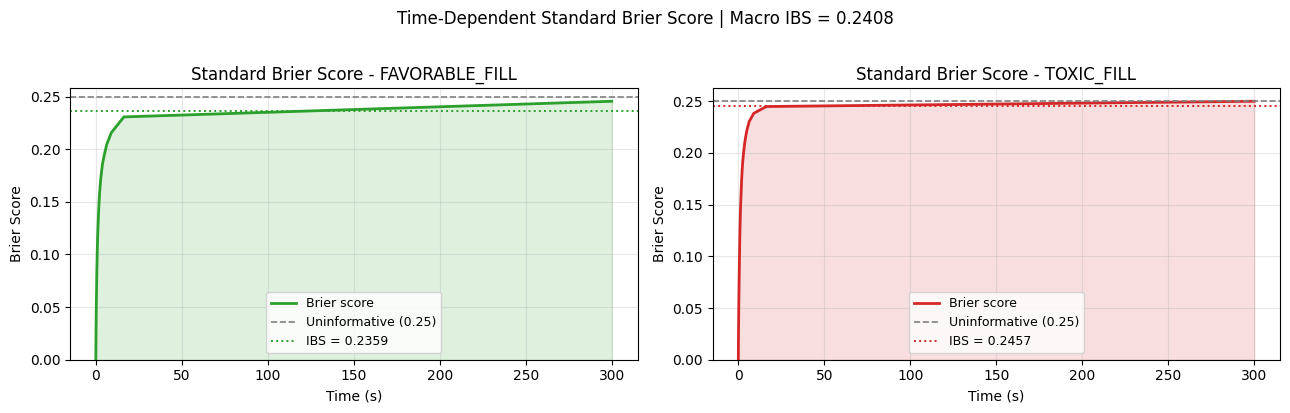

In [ ]:
# Time-dependent standard Brier score for competing risks.
import numpy as np
import matplotlib.pyplot as plt

print("Time-Dependent Standard Brier Score (Competing Risks)")
print("Using the standard formulation (low censoring regime).")

def standard_brier_score(
    durations: np.ndarray,
    events: np.ndarray,
    cif_k: np.ndarray,
    event_code: int,
    time_grid: np.ndarray,
) -> np.ndarray:
    """Compute standard Brier score for a specific cause at each time point."""
    T = len(time_grid)
    bs = np.zeros(T)

    for j, t in enumerate(time_grid):
        label = ((durations <= t) & (events == event_code)).astype(float)
        residual = (label - cif_k[j, :]) ** 2
        bs[j] = np.mean(residual)

    return bs

# Compute Brier score curves for each event.
bs_curves = {}
for k, (event_code, event_name) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
    bs_curves[event_name] = standard_brier_score(
        durations=Y_test,
        events=D_test,
        cif_k=cif_test[k],
        event_code=event_code,
        time_grid=time_grid,
)
    print(f"  {event_name:<20}: BS range [{bs_curves[event_name].min():.4f}, {bs_curves[event_name].max():.4f}]")

# Integrated Brier score (IBS) via trapezoidal integration.
t_min, t_max = time_grid[0], time_grid[-1]
_trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

ibs_scores = {}
for event_name, bs_arr in bs_curves.items():
    ibs_scores[event_name] = _trapz(bs_arr, time_grid) / (t_max - t_min)

macro_ibs = float(np.mean(list(ibs_scores.values())))

print("\nIntegrated Brier Score (IBS) per event:")
for event_name, ibs in ibs_scores.items():
    print(f"  {event_name:<20}: IBS = {ibs:.4f}")
print(f"\nMacro-average IBS: {macro_ibs:.4f}")
print("Reference: IBS=0.25 for an uninformative model")

colors_bs = {"FAVORABLE_FILL": "#2ca02c", "TOXIC_FILL": "#d62728"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, (event_name, bs_arr) in zip(axes, bs_curves.items()):
    ibs_val = ibs_scores[event_name]
    color = colors_bs.get(event_name, "#1f77b4")

    ax.plot(time_grid, bs_arr, color=color, linewidth=2, label="Brier score")
    ax.fill_between(time_grid, bs_arr, alpha=0.15, color=color)
    ax.axhline(0.25, color="grey", linestyle="--", linewidth=1.2, label="Uninformative (0.25)")
    ax.axhline(ibs_val, color=color, linestyle=":", linewidth=1.4, label=f"IBS = {ibs_val:.4f}")
    ax.set_title(f"Standard Brier Score - {event_name}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Brier Score")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle(f"Time-Dependent Standard Brier Score | Macro IBS = {macro_ibs:.4f}", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()